# DBSCAN Clustering Demo (Custom Implementation)

## Overview

In this notebook, we demonstrate a custom implementation of DBSCAN using the `make_moons` dataset.

DBSCAN is a density-based clustering algorithm that:

- Does not require specifying the number of clusters
- Can detect arbitrarily shaped clusters
- Identifies noise points (outliers)

We will:

1. Generate a non-linear dataset
2. Visualize raw data
3. Fit custom DBSCAN
4. Visualize clustering results
5. Compare with true labels

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

from rice_ml import DBSCAN

## Dataset: make_moons

We use the `make_moons` dataset from scikit-learn.

This dataset is useful for DBSCAN because:

- It contains two interleaving crescent-shaped clusters
- The clusters are not linearly separable
- It highlights DBSCAN’s ability to find non-convex shapes

We also add noise to make the problem more realistic.

In [2]:
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

print("Dataset shape:", X.shape)

Dataset shape: (300, 2)


## Visualizing the Raw Data

Before applying clustering, we visualize the dataset.

We expect:

- Two curved clusters
- Slight overlap due to noise
- No linear separation

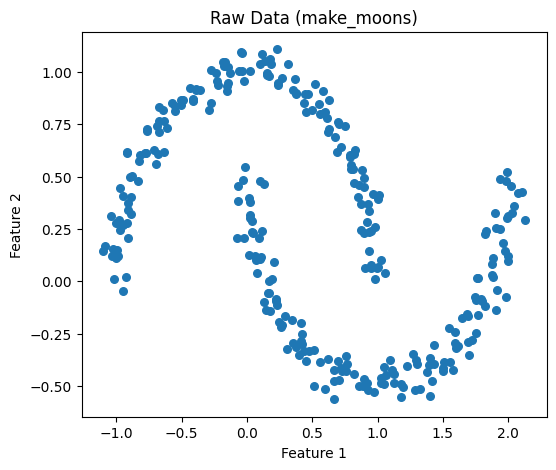

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Raw Data (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Fitting DBSCAN

We now apply our custom DBSCAN implementation.

DBSCAN works by:

- Finding points within a radius `eps`
- Marking dense regions as clusters
- Expanding clusters from core points
- Labeling sparse points as noise (-1)

In [4]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)

labels = dbscan.labels_

print("Unique labels:", np.unique(labels))

Unique labels: [0 1]


## Cluster Visualization

We visualize the resulting clusters.

- Each color represents a cluster
- `-1` represents noise points

DBSCAN can detect arbitrarily shaped clusters.

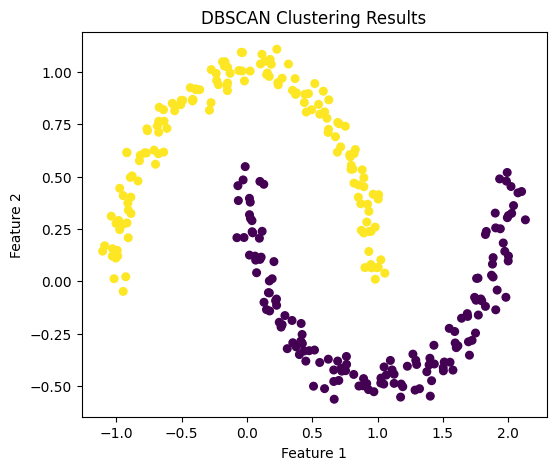

In [5]:
plt.figure(figsize=(6, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=30
)

plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Comparing with True Labels

We compare DBSCAN results with the true labels from `make_moons`.

Note:

- Cluster IDs may not match true labels
- This is only for visualization

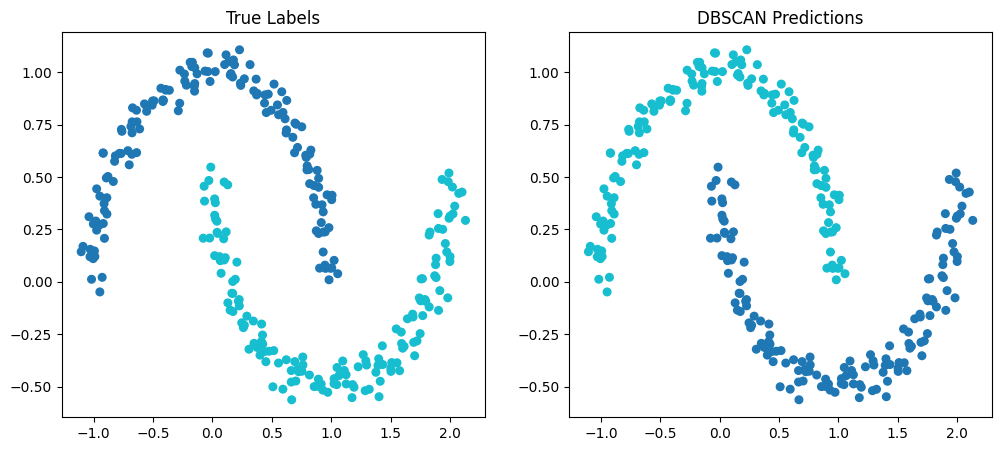

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=30)
plt.title("True Labels")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=30)
plt.title("DBSCAN Predictions")

plt.show()

## Key Takeaways

- DBSCAN does not require specifying number of clusters
- It handles non-linear cluster shapes well
- It naturally detects noise points
- It works well on datasets like `make_moons` where K-Means fails